# 10 — Claim Frequency Models

## Projet : AI Business Advisor V2

### Objectif

L'objectif est de modéliser la fréquence attendue des sinistres
pour une police d'assurance automobile.

Contrairement au modèle Claim Occurrence, la cible n'est plus
une variable binaire.

La variable observée est :

`ClaimNb`

qui représente le nombre de sinistres.

Chaque police possède également une durée d'exposition :

`Exposure`

La modélisation doit donc prendre en compte le fait que deux polices
ayant le même nombre de sinistres mais des expositions différentes
ne présentent pas la même fréquence de risque.

La fréquence observée peut être représentée par :

`ClaimNb / Exposure`

Cependant, l'exposition doit être prise en compte comme poids
ou offset lors de la modélisation.

Les modèles seront comparés uniquement sur le jeu de développement.

Le jeu de test utilisé par Claim Occurrence reste également le
holdout final pour Claim Frequency et ne sera pas utilisé durant
la sélection des modèles.

In [1]:
import pandas as pd
import numpy as np

import json
import time

import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.base import clone

from sklearn.model_selection import StratifiedKFold

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import PoissonRegressor

from sklearn.metrics import (
    mean_poisson_deviance,
    mean_absolute_error
)

from xgboost import XGBRegressor


RANDOM_STATE = 42

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.width",
    200
)

In [2]:
cwd = Path.cwd()

possible_processed_paths = [
    cwd / "data" / "processed",
    cwd / "data-science" / "data" / "processed",
    cwd.parent / "data" / "processed"
]

PROCESSED_DIR = None

for path in possible_processed_paths:

    if path.exists():

        PROCESSED_DIR = path
        break


if PROCESSED_DIR is None:

    raise FileNotFoundError(
        "Impossible de localiser data/processed"
    )


DATA_DIR = (
    PROCESSED_DIR.parent
)

METADATA_DIR = (
    DATA_DIR
    / "metadata"
)

REPORT_DIR = (
    DATA_DIR.parent
    / "reports"
    / "models"
    / "claim_frequency"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


frequency = pd.read_csv(
    PROCESSED_DIR
    / "claim_frequency_modeling_base.csv"
)


split_df = pd.read_csv(
    METADATA_DIR
    / "freMTPL2_split.csv"
)


print(
    "Frequency :",
    frequency.shape
)

Frequency : (676789, 12)


In [3]:
frequency = frequency.merge(
    split_df,
    on="IDpol",
    how="left",
    validate="one_to_one"
)


frequency_dev = (
    frequency[
        frequency["split"]
        == "development"
    ]
    .copy()
)

frequency_test = (
    frequency[
        frequency["split"]
        == "test"
    ]
    .copy()
)


print(
    "DEV :",
    frequency_dev.shape
)

print(
    "TEST :",
    frequency_test.shape
)

DEV : (541431, 13)
TEST : (135358, 13)


In [4]:
assert set(
    frequency_dev["IDpol"]
).isdisjoint(
    set(
        frequency_test["IDpol"]
    )
)

print(
    "Holdout integrity : OK"
)

Holdout integrity : OK


In [5]:
with open(
    METADATA_DIR
    / "feature_manifest.json",
    "r",
    encoding="utf-8"
) as f:

    feature_manifest = json.load(f)


frequency_config = (
    feature_manifest[
        "claim_frequency"
    ]
)


numeric_features = (
    frequency_config[
        "numeric_features"
    ]
)

categorical_features = (
    frequency_config[
        "categorical_features"
    ]
)

features = (
    numeric_features
    +
    categorical_features
)

In [6]:
X_dev = (
    frequency_dev[
        features
    ]
    .copy()
)

y_count_dev = (
    frequency_dev[
        "ClaimNb"
    ]
    .copy()
)

exposure_dev = (
    frequency_dev[
        "Exposure"
    ]
    .copy()
)

In [7]:
y_rate_dev = (
    y_count_dev
    /
    exposure_dev
)

In [8]:
print(
    "Claim count :"
)

print(
    y_count_dev.describe()
)

print()

print(
    "Exposure :"
)

print(
    exposure_dev.describe()
)

print()

print(
    "Observed claim rate :"
)

print(
    y_rate_dev.describe()
)

Claim count :
count    541431.000000
mean          0.053224
std           0.239873
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          16.000000
Name: ClaimNb, dtype: float64

Exposure :
count    541431.000000
mean          0.527370
std           0.363798
min           0.002732
25%           0.170000
50%           0.490000
75%           0.990000
max           1.000000
Name: Exposure, dtype: float64

Observed claim rate :
count    541431.000000
mean          0.268137
std           4.750863
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         732.000000
dtype: float64


In [9]:
portfolio_frequency = (
    y_count_dev.sum()
    /
    exposure_dev.sum()
)

print(
    "Portfolio claim frequency :",
    portfolio_frequency
)

Portfolio claim frequency : 0.10092303350726638


In [10]:
frequency_strata = (
    y_count_dev > 0
).astype(int)

In [11]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [12]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [13]:
tree_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)


tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            tree_numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [14]:
poisson_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            linear_preprocessor
        ),
        (
            "model",
            PoissonRegressor(
                alpha=1.0,
                max_iter=500
            )
        )
    ]
)

In [15]:
xgb_frequency_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "model",
            XGBRegressor(
                objective="count:poisson",
                eval_metric="poisson-nloglik",
                n_estimators=300,
                learning_rate=0.05,
                max_depth=5,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_lambda=1.0,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                tree_method="hist"
            )
        )
    ]
)

In [16]:
def evaluate_frequency_model_cv(
    model_name,
    pipeline,
    X,
    y_count,
    exposure,
    strata,
    cv
):

    fold_results = []

    start_total = (
        time.perf_counter()
    )


    for fold_id, (
        train_idx,
        val_idx
    ) in enumerate(
        cv.split(
            X,
            strata
        ),
        start=1
    ):

        X_train = (
            X.iloc[
                train_idx
            ]
        )

        X_val = (
            X.iloc[
                val_idx
            ]
        )


        y_count_train = (
            y_count.iloc[
                train_idx
            ]
        )

        y_count_val = (
            y_count.iloc[
                val_idx
            ]
        )


        exposure_train = (
            exposure.iloc[
                train_idx
            ]
        )

        exposure_val = (
            exposure.iloc[
                val_idx
            ]
        )


        y_rate_train = (
            y_count_train
            /
            exposure_train
        )


        model = clone(
            pipeline
        )


        start_fold = (
            time.perf_counter()
        )


        model.fit(
            X_train,
            y_rate_train,
            model__sample_weight=(
                exposure_train
            )
        )


        fit_time = (
            time.perf_counter()
            -
            start_fold
        )


        predicted_rate = (
            model.predict(
                X_val
            )
        )


        predicted_rate = (
            np.clip(
                predicted_rate,
                1e-9,
                None
            )
        )


        predicted_count = (
            predicted_rate
            *
            exposure_val
        )


        # Poisson deviance au niveau du nombre
        poisson_deviance = (
            mean_poisson_deviance(
                y_count_val,
                predicted_count
            )
        )


        # MAE sur le nombre attendu
        count_mae = (
            mean_absolute_error(
                y_count_val,
                predicted_count
            )
        )


        observed_frequency = (
            y_count_val.sum()
            /
            exposure_val.sum()
        )


        predicted_frequency = (
            predicted_count.sum()
            /
            exposure_val.sum()
        )


        fold_results.append({
            "model":
                model_name,

            "fold":
                fold_id,

            "poisson_deviance":
                poisson_deviance,

            "count_mae":
                count_mae,

            "observed_frequency":
                observed_frequency,

            "predicted_frequency":
                predicted_frequency,

            "fit_time":
                fit_time
        })


    total_time = (
        time.perf_counter()
        -
        start_total
    )


    results = pd.DataFrame(
        fold_results
    )


    summary = {
        "model":
            model_name,

        "poisson_deviance_mean":
            results[
                "poisson_deviance"
            ].mean(),

        "poisson_deviance_std":
            results[
                "poisson_deviance"
            ].std(),

        "count_mae_mean":
            results[
                "count_mae"
            ].mean(),

        "observed_frequency_mean":
            results[
                "observed_frequency"
            ].mean(),

        "predicted_frequency_mean":
            results[
                "predicted_frequency"
            ].mean(),

        "fit_time_mean":
            results[
                "fit_time"
            ].mean(),

        "total_time":
            total_time
    }


    return (
        results,
        summary
    )

In [17]:
def evaluate_constant_frequency_cv(
    y_count,
    exposure,
    strata,
    cv
):

    fold_results = []

    for fold_id, (
        train_idx,
        val_idx
    ) in enumerate(
        cv.split(
            np.zeros(len(y_count)),
            strata
        ),
        start=1
    ):

        y_train = (
            y_count.iloc[
                train_idx
            ]
        )

        y_val = (
            y_count.iloc[
                val_idx
            ]
        )

        exposure_train = (
            exposure.iloc[
                train_idx
            ]
        )

        exposure_val = (
            exposure.iloc[
                val_idx
            ]
        )

        # ---------------------------------------------------
        # Fréquence moyenne apprise uniquement sur TRAIN
        # ---------------------------------------------------

        train_frequency = (
            y_train.sum()
            /
            exposure_train.sum()
        )

        # ---------------------------------------------------
        # Même fréquence prédite pour tous les contrats
        # ---------------------------------------------------

        predicted_rate = np.full(
            shape=len(y_val),
            fill_value=train_frequency,
            dtype=float
        )

        predicted_count = (
            predicted_rate
            *
            exposure_val.to_numpy()
        )

        predicted_count = np.clip(
            predicted_count,
            1e-9,
            None
        )

        # ---------------------------------------------------
        # Métriques
        # ---------------------------------------------------

        poisson_deviance = (
            mean_poisson_deviance(
                y_val,
                predicted_count
            )
        )

        count_mae = (
            mean_absolute_error(
                y_val,
                predicted_count
            )
        )

        observed_frequency = (
            y_val.sum()
            /
            exposure_val.sum()
        )

        predicted_frequency = (
            predicted_count.sum()
            /
            exposure_val.sum()
        )

        fold_results.append({
            "model":
                "constant_frequency",

            "fold":
                fold_id,

            "poisson_deviance":
                poisson_deviance,

            "count_mae":
                count_mae,

            "observed_frequency":
                observed_frequency,

            "predicted_frequency":
                predicted_frequency,

            "fit_time":
                0.0
        })

    results = pd.DataFrame(
        fold_results
    )

    summary = {
        "model":
            "constant_frequency",

        "poisson_deviance_mean":
            results[
                "poisson_deviance"
            ].mean(),

        "poisson_deviance_std":
            results[
                "poisson_deviance"
            ].std(),

        "count_mae_mean":
            results[
                "count_mae"
            ].mean(),

        "observed_frequency_mean":
            results[
                "observed_frequency"
            ].mean(),

        "predicted_frequency_mean":
            results[
                "predicted_frequency"
            ].mean(),

        "fit_time_mean":
            0.0,

        "total_time":
            0.0
    }

    return (
        results,
        summary
    )

In [19]:
constant_fold_results, constant_summary = (
    evaluate_constant_frequency_cv(
        y_count=y_count_dev,
        exposure=exposure_dev,
        strata=frequency_strata,
        cv=cv
    )
)
constant_fold_results

,model,fold,poisson_deviance,count_mae,observed_frequency,predicted_frequency,fit_time
0,constant_frequency,1,0.330322,0.100027,0.100944,0.100918,0.0
1,constant_frequency,2,0.330126,0.099830,0.100687,0.100982,0.0
2,constant_frequency,3,0.333035,0.100272,0.101198,0.100854,0.0
3,constant_frequency,4,0.330285,0.099690,0.101164,0.100863,0.0
4,constant_frequency,5,0.330957,0.099908,0.100622,0.100998,0.0


In [20]:
constant_summary

{'model': 'constant_frequency',
 'poisson_deviance_mean': np.float64(0.3309451427002972),
 'poisson_deviance_std': np.float64(0.0012106956842108934),
 'count_mae_mean': np.float64(0.09994524072765261),
 'observed_frequency_mean': np.float64(0.10092309738842616),
 'predicted_frequency_mean': np.float64(0.10092303742290092),
 'fit_time_mean': 0.0,
 'total_time': 0.0}

In [21]:
print(
    "Portfolio frequency DEV :",
    portfolio_frequency
)

print(
    "CV observed frequency :",
    constant_summary[
        "observed_frequency_mean"
    ]
)

print(
    "CV predicted frequency :",
    constant_summary[
        "predicted_frequency_mean"
    ]
)

print(
    "Poisson deviance :",
    constant_summary[
        "poisson_deviance_mean"
    ]
)

print(
    "Count MAE :",
    constant_summary[
        "count_mae_mean"
    ]
)

Portfolio frequency DEV : 0.10092303350726638
CV observed frequency : 0.10092309738842616
CV predicted frequency : 0.10092303742290092
Poisson deviance : 0.3309451427002972
Count MAE : 0.09994524072765261


In [22]:
poisson_fold_results, poisson_summary = (
    evaluate_frequency_model_cv(
        model_name="poisson_regressor",
        pipeline=poisson_pipeline,
        X=X_dev,
        y_count=y_count_dev,
        exposure=exposure_dev,
        strata=frequency_strata,
        cv=cv
    )
)

In [23]:
poisson_fold_results

,model,fold,poisson_deviance,count_mae,observed_frequency,predicted_frequency,fit_time
0,poisson_regressor,1,0.328546,0.099965,0.100944,0.100944,1.459134
1,poisson_regressor,2,0.328252,0.099765,0.100687,0.101006,1.533334
2,poisson_regressor,3,0.331116,0.100184,0.101198,0.100838,1.665350
3,poisson_regressor,4,0.328420,0.099614,0.101164,0.100871,1.570781
4,poisson_regressor,5,0.329149,0.099825,0.100622,0.100974,2.137814


In [24]:
poisson_summary

{'model': 'poisson_regressor',
 'poisson_deviance_mean': np.float64(0.32909655093840756),
 'poisson_deviance_std': np.float64(0.0011782758496582564),
 'count_mae_mean': np.float64(0.09987059829109488),
 'observed_frequency_mean': np.float64(0.10092309738842616),
 'predicted_frequency_mean': np.float64(0.10092650462131916),
 'fit_time_mean': np.float64(1.6732827399973758),
 'total_time': 10.274130599980708}

In [25]:
frequency_results = pd.DataFrame([
    constant_summary,
    poisson_summary
])

In [26]:
frequency_results[
    [
        "model",
        "poisson_deviance_mean",
        "poisson_deviance_std",
        "count_mae_mean",
        "observed_frequency_mean",
        "predicted_frequency_mean",
        "fit_time_mean"
    ]
].round(6)

,model,poisson_deviance_mean,poisson_deviance_std,count_mae_mean,observed_frequency_mean,predicted_frequency_mean,fit_time_mean
0,constant_frequency,0.330945,0.001211,0.099945,0.100923,0.100923,0.000000
1,poisson_regressor,0.329097,0.001178,0.099871,0.100923,0.100927,1.673283


In [27]:
frequency_results.to_csv(
    REPORT_DIR
    / "frequency_baseline_poisson_comparison.csv",
    index=False
)

In [28]:
frequency_results[
    [
        "model",
        "observed_frequency_mean",
        "predicted_frequency_mean"
    ]
]

,model,observed_frequency_mean,predicted_frequency_mean
0,constant_frequency,0.100923,0.100923
1,poisson_regressor,0.100923,0.100927


In [29]:
constant_deviance = (
    constant_summary[
        "poisson_deviance_mean"
    ]
)

poisson_deviance = (
    poisson_summary[
        "poisson_deviance_mean"
    ]
)

poisson_deviance_improvement = (
    (
        constant_deviance
        -
        poisson_deviance
    )
    /
    constant_deviance
    *
    100
)

print(
    f"Amélioration Poisson Deviance : "
    f"{poisson_deviance_improvement:.2f}%"
)

Amélioration Poisson Deviance : 0.56%


In [30]:
poisson_fold_results[
    [
        "fold",
        "poisson_deviance",
        "observed_frequency",
        "predicted_frequency"
    ]
]

,fold,poisson_deviance,observed_frequency,predicted_frequency
0,1,0.328546,0.100944,0.100944
1,2,0.328252,0.100687,0.101006
2,3,0.331116,0.101198,0.100838
3,4,0.328420,0.101164,0.100871
4,5,0.329149,0.100622,0.100974


In [31]:
print(
    "Poisson deviance mean :",
    poisson_summary[
        "poisson_deviance_mean"
    ]
)

print(
    "Poisson deviance std :",
    poisson_summary[
        "poisson_deviance_std"
    ]
)

Poisson deviance mean : 0.32909655093840756
Poisson deviance std : 0.0011782758496582564


In [32]:
poisson_check_model = clone(
    poisson_pipeline
)

poisson_check_model.fit(
    X_dev,
    y_rate_dev,
    model__sample_weight=exposure_dev
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['VehPower','VehAge','DrivAge',...,'VehBrand','VehGas','Region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of colu

In [33]:
poisson_dev_pred_rate = (
    poisson_check_model
    .predict(
        X_dev
    )
)

pd.Series(
    poisson_dev_pred_rate
).describe(
    percentiles=[
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99
    ]
)

count    541431.000000
mean          0.101797
std           0.004573
min           0.071961
1%            0.093694
5%            0.095579
25%           0.098675
50%           0.101092
75%           0.104114
95%           0.110620
99%           0.115123
max           0.147283
dtype: float64

In [34]:
print(
    "Minimum predicted frequency :",
    poisson_dev_pred_rate.min()
)

print(
    "Maximum predicted frequency :",
    poisson_dev_pred_rate.max()
)

print(
    "Negative predictions :",
    (
        poisson_dev_pred_rate < 0
    ).sum()
)

Minimum predicted frequency : 0.07196143227341088
Maximum predicted frequency : 0.14728325248715446
Negative predictions : 0


In [36]:
xgb_frequency_fold_results, xgb_frequency_summary = (
    evaluate_frequency_model_cv(
        model_name="xgboost_poisson",
        pipeline=xgb_frequency_pipeline,
        X=X_dev,
        y_count=y_count_dev,
        exposure=exposure_dev,
        strata=frequency_strata,
        cv=cv
    )
)
xgb_frequency_fold_results

,model,fold,poisson_deviance,count_mae,observed_frequency,predicted_frequency,fit_time
0,xgboost_poisson,1,0.303681,0.096820,0.100944,0.100899,16.077847
1,xgboost_poisson,2,0.303911,0.096785,0.100687,0.101810,12.722393
2,xgboost_poisson,3,0.305982,0.096697,0.101198,0.100373,11.667592
3,xgboost_poisson,4,0.302970,0.096402,0.101164,0.101037,11.343405
4,xgboost_poisson,5,0.302077,0.096328,0.100622,0.100459,11.198796


In [37]:
xgb_frequency_summary

{'model': 'xgboost_poisson',
 'poisson_deviance_mean': np.float64(0.30372406859641077),
 'poisson_deviance_std': np.float64(0.0014505036955159954),
 'count_mae_mean': np.float64(0.09660655923190478),
 'observed_frequency_mean': np.float64(0.10092309738842616),
 'predicted_frequency_mean': np.float64(0.10091554023384756),
 'fit_time_mean': np.float64(12.602006260008784),
 'total_time': 67.24665919999825}

In [38]:
frequency_results = pd.DataFrame([
    constant_summary,
    poisson_summary,
    xgb_frequency_summary
])

In [39]:
frequency_comparison = (
    frequency_results[
        [
            "model",
            "poisson_deviance_mean",
            "poisson_deviance_std",
            "count_mae_mean",
            "observed_frequency_mean",
            "predicted_frequency_mean",
            "fit_time_mean",
            "total_time"
        ]
    ]
    .sort_values(
        "poisson_deviance_mean"
    )
    .reset_index(
        drop=True
    )
)

frequency_comparison.round(6)

,model,poisson_deviance_mean,poisson_deviance_std,count_mae_mean,observed_frequency_mean,predicted_frequency_mean,fit_time_mean,total_time
0,xgboost_poisson,0.303724,0.001451,0.096607,0.100923,0.100916,12.602006,67.246659
1,poisson_regressor,0.329097,0.001178,0.099871,0.100923,0.100927,1.673283,10.274131
2,constant_frequency,0.330945,0.001211,0.099945,0.100923,0.100923,0.000000,0.000000


In [40]:
frequency_comparison.to_csv(
    REPORT_DIR
    / "claim_frequency_cv_comparison.csv",
    index=False
)

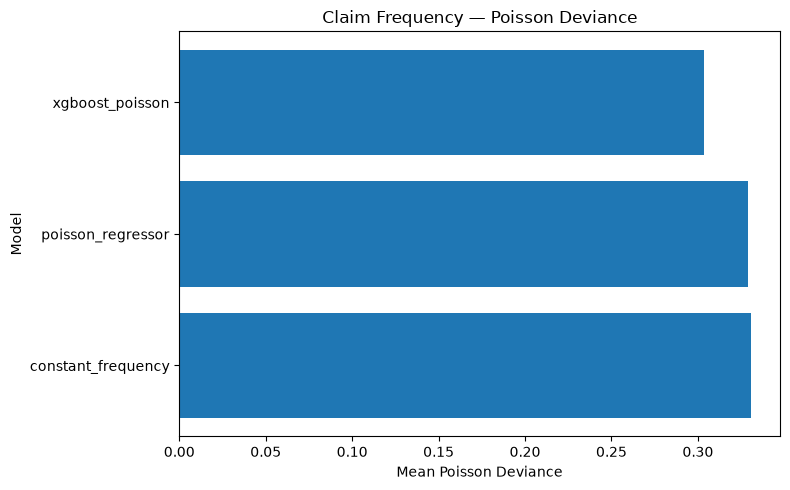

In [41]:
plot_data = (
    frequency_comparison
    .sort_values(
        "poisson_deviance_mean",
        ascending=False
    )
)

plt.figure(
    figsize=(8, 5)
)

plt.barh(
    plot_data["model"],
    plot_data[
        "poisson_deviance_mean"
    ]
)

plt.xlabel(
    "Mean Poisson Deviance"
)

plt.ylabel(
    "Model"
)

plt.title(
    "Claim Frequency — Poisson Deviance"
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "frequency_poisson_deviance_comparison.png",
    dpi=150
)

plt.show()

In [42]:
frequency_comparison[
    [
        "model",
        "observed_frequency_mean",
        "predicted_frequency_mean"
    ]
]

,model,observed_frequency_mean,predicted_frequency_mean
0,xgboost_poisson,0.100923,0.100916
1,poisson_regressor,0.100923,0.100927
2,constant_frequency,0.100923,0.100923


In [43]:
frequency_comparison[
    "frequency_bias"
] = (
    frequency_comparison[
        "predicted_frequency_mean"
    ]
    -
    frequency_comparison[
        "observed_frequency_mean"
    ]
)

In [44]:
frequency_comparison[
    "frequency_bias_pct"
] = (
    frequency_comparison[
        "frequency_bias"
    ]
    /
    frequency_comparison[
        "observed_frequency_mean"
    ]
    *
    100
)

In [45]:
frequency_comparison[
    [
        "model",
        "observed_frequency_mean",
        "predicted_frequency_mean",
        "frequency_bias",
        "frequency_bias_pct"
    ]
].round(6)

,model,observed_frequency_mean,predicted_frequency_mean,frequency_bias,frequency_bias_pct
0,xgboost_poisson,0.100923,0.100916,-0.000008,-0.007488
1,poisson_regressor,0.100923,0.100927,0.000003,0.003376
2,constant_frequency,0.100923,0.100923,-0.000000,-0.000059


In [46]:
print(
    "=" * 80
)

print(
    "CLAIM FREQUENCY — INITIAL MODEL RESULTS"
)

print(
    "=" * 80
)


print(
    "\n=== PORTFOLIO ==="
)

print(
    f"Development policies : "
    f"{len(frequency_dev)}"
)

print(
    f"Total claims : "
    f"{y_count_dev.sum()}"
)

print(
    f"Total exposure : "
    f"{exposure_dev.sum():.6f}"
)

print(
    f"Portfolio frequency : "
    f"{portfolio_frequency:.6f}"
)


print(
    "\n=== MODEL COMPARISON ==="
)

print(
    frequency_comparison
    .round(6)
    .to_string(
        index=False
    )
)


print(
    "\n=== CONSTANT BASELINE ==="
)

for key, value in (
    constant_summary.items()
):

    print(
        key,
        "=",
        value
    )


print(
    "\n=== POISSON REGRESSOR ==="
)

for key, value in (
    poisson_summary.items()
):

    print(
        key,
        "=",
        value
    )


print(
    "\n=== XGBOOST POISSON ==="
)

for key, value in (
    xgb_frequency_summary.items()
):

    print(
        key,
        "=",
        value
    )


print(
    "\n=== POISSON IMPROVEMENT VS BASELINE ==="
)

print(
    f"{poisson_deviance_improvement:.4f}%"
)


xgb_improvement = (
    (
        constant_summary[
            "poisson_deviance_mean"
        ]
        -
        xgb_frequency_summary[
            "poisson_deviance_mean"
        ]
    )
    /
    constant_summary[
        "poisson_deviance_mean"
    ]
    *
    100
)


print(
    "\n=== XGBOOST IMPROVEMENT VS BASELINE ==="
)

print(
    f"{xgb_improvement:.4f}%"
)


print(
    "\n=== FOLD DETAILS — POISSON ==="
)

print(
    poisson_fold_results
    .round(6)
    .to_string(
        index=False
    )
)


print(
    "\n=== FOLD DETAILS — XGBOOST ==="
)

print(
    xgb_frequency_fold_results
    .round(6)
    .to_string(
        index=False
    )
)


print(
    "\nTEST FINAL UTILISÉ ? NON"
)

print(
    "=" * 80
)

CLAIM FREQUENCY — INITIAL MODEL RESULTS

=== PORTFOLIO ===
Development policies : 541431
Total claims : 28817
Total exposure : 285534.421614
Portfolio frequency : 0.100923

=== MODEL COMPARISON ===
             model  poisson_deviance_mean  poisson_deviance_std  count_mae_mean  observed_frequency_mean  predicted_frequency_mean  fit_time_mean  total_time  frequency_bias  frequency_bias_pct
   xgboost_poisson               0.303724              0.001451        0.096607                 0.100923                  0.100916      12.602006   67.246659       -0.000008           -0.007488
 poisson_regressor               0.329097              0.001178        0.099871                 0.100923                  0.100927       1.673283   10.274131        0.000003            0.003376
constant_frequency               0.330945              0.001211        0.099945                 0.100923                  0.100923       0.000000    0.000000       -0.000000           -0.000059

=== CONSTANT BASELINE ===

# Analyse comparative — Claim Frequency

## Contexte

Le jeu de développement contient :

- 541 431 polices ;
- 28 817 sinistres ;
- 285 534.42 unités d'exposition.

La fréquence globale observée est :

**0.100923 sinistre par unité d'exposition.**

La métrique principale utilisée pour comparer les modèles est la
Mean Poisson Deviance.

Une valeur plus faible indique une meilleure adéquation entre les
nombres de sinistres observés et les nombres attendus.

---

## Constant Frequency Baseline

La baseline prédit la même fréquence pour tous les contrats.

Poisson Deviance :

**0.330945**

Count MAE :

**0.099945**

Fréquence observée :

**0.100923**

Fréquence prédite :

**0.100923**

Cette baseline reproduit naturellement la fréquence globale du portefeuille,
mais elle ne permet aucune différenciation individuelle du risque.

Elle constitue donc le niveau minimal que les modèles supervisés doivent
dépasser.

---

## PoissonRegressor

Poisson Deviance :

**0.329097 ± 0.001178**

Count MAE :

**0.099871**

Fréquence observée moyenne :

**0.100923**

Fréquence prédite moyenne :

**0.100927**

Temps moyen d'entraînement :

**1.67 secondes par fold**

L'amélioration de PoissonRegressor par rapport à la baseline constante est :

**0.5586 %**

Le modèle améliore donc légèrement la baseline mais le gain reste limité.

La fréquence globale prédite reste très proche de la fréquence observée,
ce qui indique une bonne calibration globale du portefeuille.

Le gain limité suggère cependant qu'une formulation essentiellement
linéaire ne représente qu'une partie des relations présentes dans
les données.

---

## XGBoost Poisson

Poisson Deviance :

**0.303724 ± 0.001451**

Count MAE :

**0.096607**

Fréquence observée moyenne :

**0.100923**

Fréquence prédite moyenne :

**0.100916**

Temps moyen d'entraînement :

**12.60 secondes par fold**

XGBoost réduit la Poisson Deviance de :

**8.2253 %**

par rapport à la baseline constante.

Il réduit également la deviance d'environ :

**7.71 %**

par rapport à PoissonRegressor.

Cette amélioration est nettement supérieure à celle obtenue avec
PoissonRegressor.

Elle suggère que les données contiennent des relations non linéaires
et/ou des interactions entre variables que le modèle Poisson linéaire
ne représente pas complètement.

---

## Stabilité

Les Poisson Deviances obtenues par XGBoost sur les cinq folds sont :

- 0.303681
- 0.303911
- 0.305982
- 0.302970
- 0.302077

L'écart-type est seulement de :

**0.001451**

Les performances sont donc relativement stables entre les folds.

La fréquence globale prédite reste également très proche de la fréquence
observée sur chaque fold.

---

## Comparaison

| Modèle | Poisson Deviance | Std | Count MAE | Fréquence prédite |
|---|---:|---:|---:|---:|
| Constant Frequency | 0.330945 | 0.001211 | 0.099945 | 0.100923 |
| PoissonRegressor | 0.329097 | 0.001178 | 0.099871 | 0.100927 |
| XGBoost Poisson | **0.303724** | 0.001451 | **0.096607** | 0.100916 |

XGBoost présente la meilleure performance prédictive tout en maintenant
une fréquence globale très proche de celle réellement observée.

---

# Conclusion provisoire

XGBoost Poisson est retenu comme candidat principal pour l'étape de tuning.

PoissonRegressor est conservé comme baseline actuarielle interprétable.

La prochaine étape consistera à ajuster les hyperparamètres des deux modèles,
avec une priorité donnée à XGBoost.

Le jeu de test Frequency n'est pas utilisé durant cette sélection.